In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples

# Set a seed for reproducibility
SEED = 42

# Colors for plotting
BLUE = '#1f77b4'
TEAL = '#2ca02c'
GREY = '#999999'
PALE = '#dddddd'

print("✅ All imports successful!")

✅ All imports successful!


X shape: (1200, 2)   (rows = points, columns = features)
True cluster sizes: [300 300 300 300]
Total points: 1200


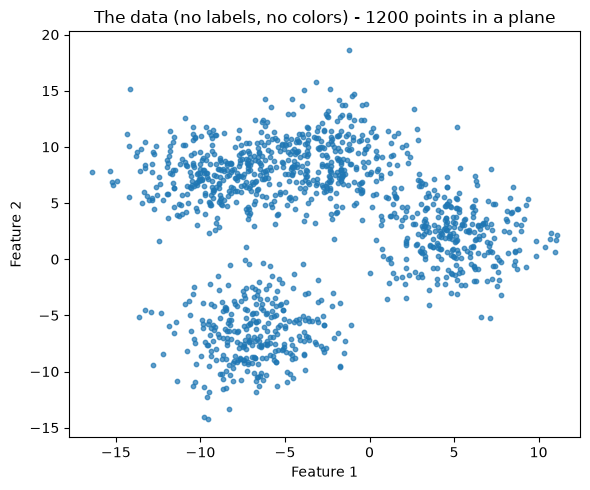

In [8]:
# Generate the data with original settings
TRUE_K = 4          # the true number of clusters
N_SAMPLES = 1200

X, y_true = make_blobs(
    n_samples=N_SAMPLES,
    centers=TRUE_K,
    n_features=2,
    cluster_std=2.5,  # ← This is the original value
    random_state=SEED,
)

print(f'X shape: {X.shape}   (rows = points, columns = features)')
print(f'True cluster sizes: {np.bincount(y_true)}')
print(f'Total points: {len(X)}')

# Visualize the data
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(X[:, 0], X[:, 1], s=10, alpha=0.7, color=BLUE)
ax.set_title('The data (no labels, no colors) - 1200 points in a plane')
ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')
plt.tight_layout()
plt.show()

In [10]:
# Test different values of k
k_range = range(2, 11)

silhouettes = []
inertias = []

for k in k_range:
    # Fit K-Means
    model = KMeans(n_clusters=k, n_init=10, random_state=SEED)
    labels = model.fit_predict(X)
    
    # Calculate metrics
    sil_score = silhouette_score(X, labels)
    silhouettes.append(sil_score)
    inertias.append(model.inertia_)
    
    print(f"k = {k}  →  silhouette score = {sil_score:.4f}")

print(f"\n✅ Best k (highest silhouette): {list(k_range)[np.argmax(silhouettes)]}")

k = 2  →  silhouette score = 0.4828
k = 3  →  silhouette score = 0.5794
k = 4  →  silhouette score = 0.5332
k = 5  →  silhouette score = 0.4750
k = 6  →  silhouette score = 0.4022
k = 7  →  silhouette score = 0.3317
k = 8  →  silhouette score = 0.3323
k = 9  →  silhouette score = 0.3293
k = 10  →  silhouette score = 0.3344

✅ Best k (highest silhouette): 3


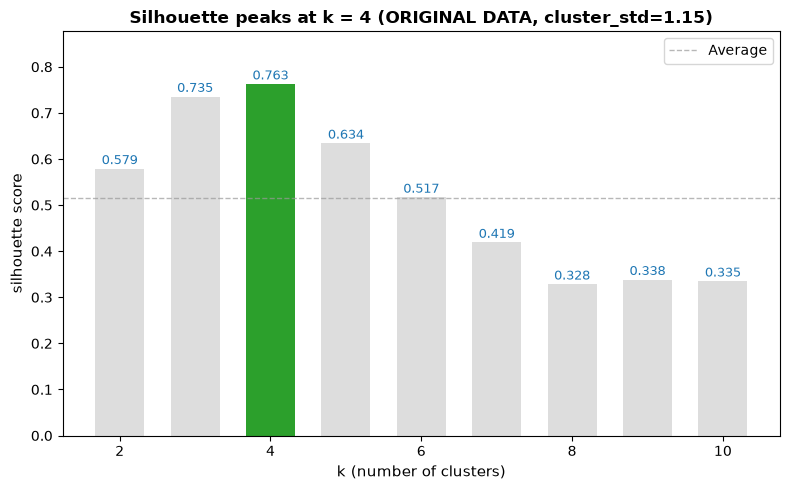

Peak silhouette score: 0.7625 at k=4


In [4]:
# Find the best k
best_k = list(k_range)[int(np.argmax(silhouettes))]

# Plot silhouette scores
fig, ax = plt.subplots(figsize=(8, 5))
colors = [TEAL if k == best_k else PALE for k in k_range]
bars = ax.bar(list(k_range), silhouettes, color=colors, width=0.65)

# Add values on top of bars
for k, s in zip(k_range, silhouettes):
    ax.text(k, s + 0.01, f'{s:.3f}', ha='center', fontsize=9, color=BLUE)

ax.axhline(y=np.mean(silhouettes), color=GREY, linestyle='--', linewidth=1, alpha=0.7, label='Average')
ax.set_xlabel('k (number of clusters)', fontsize=11)
ax.set_ylabel('silhouette score', fontsize=11)
ax.set_title(f'Silhouette peaks at k = {best_k} (ORIGINAL DATA, cluster_std=1.15)', fontsize=12, fontweight='bold')
ax.set_ylim(0, max(silhouettes) * 1.15)
ax.legend()
plt.tight_layout()
plt.show()

print(f"Peak silhouette score: {max(silhouettes):.4f} at k={best_k}")

Data created with unequal cluster sizes:
  Clusters 0, 1, 3: tight (std=0.5)
  Cluster 2: WIDE (std=3.0)
True cluster sizes: [300 300 300 300]


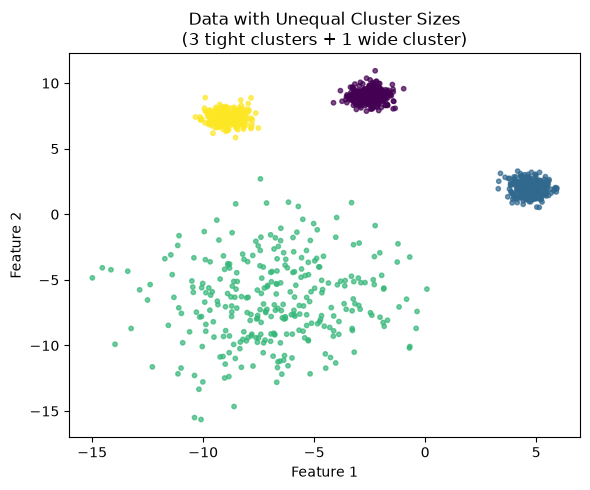

In [11]:
# Reset: create data with UNEQUAL cluster sizes
# [0.5, 0.5, 3.0, 0.5] = three tight clusters, ONE WIDE cluster
TRUE_K = 4
N_SAMPLES = 1200

X_unequal, y_true_unequal = make_blobs(
    n_samples=N_SAMPLES,
    centers=TRUE_K,
    n_features=2,
    cluster_std=[0.5, 0.5, 3.0, 0.5],  # ← Three tight (0.5), one wide (3.0)
    random_state=SEED,
)

print("Data created with unequal cluster sizes:")
print(f"  Clusters 0, 1, 3: tight (std=0.5)")
print(f"  Cluster 2: WIDE (std=3.0)")
print(f"True cluster sizes: {np.bincount(y_true_unequal)}")

# Visualize
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(X_unequal[:, 0], X_unequal[:, 1], s=10, alpha=0.7, c=y_true_unequal, cmap='viridis')
ax.set_title('Data with Unequal Cluster Sizes\n(3 tight clusters + 1 wide cluster)')
ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')
plt.tight_layout()
plt.show()

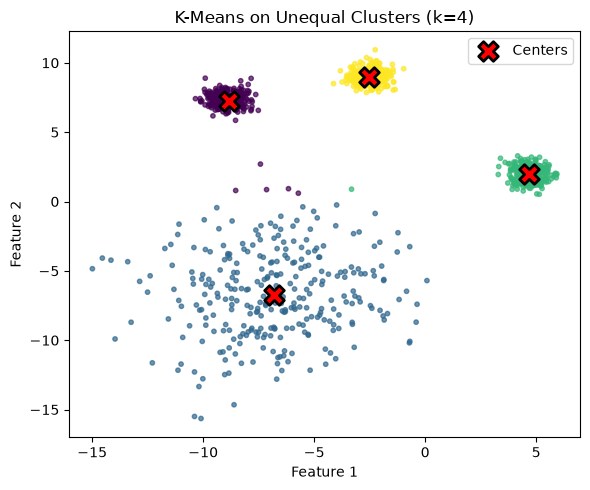

K-Means silhouette score: 0.8041


In [12]:
# K-Means with the unequal data
km_unequal = KMeans(n_clusters=4, n_init=10, random_state=SEED)
km_labels = km_unequal.fit_predict(X_unequal)

# Visualize K-Means results
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(X_unequal[:, 0], X_unequal[:, 1], s=10, alpha=0.7, c=km_labels, cmap='viridis')

# Mark cluster centers
ax.scatter(km_unequal.cluster_centers_[:, 0], km_unequal.cluster_centers_[:, 1], 
           c='red', s=200, marker='X', edgecolors='black', linewidths=2, label='Centers')

ax.set_title('K-Means on Unequal Clusters (k=4)')
ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')
ax.legend()
plt.tight_layout()
plt.show()

# Calculate silhouette
sil_km = silhouette_score(X_unequal, km_labels)
print(f"K-Means silhouette score: {sil_km:.4f}")

In [13]:
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

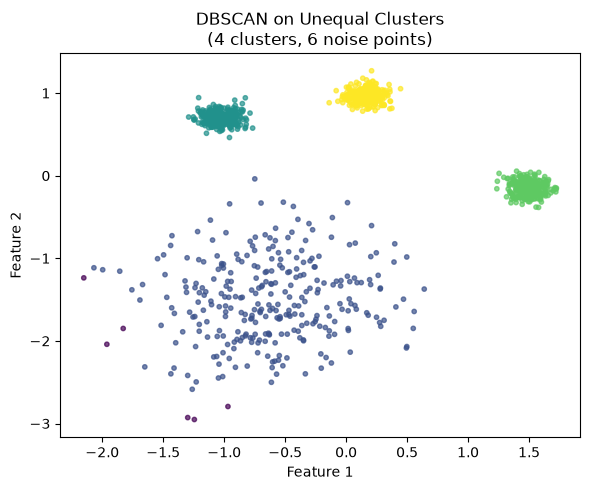

DBSCAN found 4 clusters
DBSCAN marked 6 points as noise (outliers)


In [14]:
# DBSCAN requires scaled data
scaler = StandardScaler()
X_unequal_scaled = scaler.fit_transform(X_unequal)

# DBSCAN with eps=0.3, min_samples=5
dbscan = DBSCAN(eps=0.3, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_unequal_scaled)

# Visualize DBSCAN results
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(X_unequal_scaled[:, 0], X_unequal_scaled[:, 1], s=10, alpha=0.7, 
           c=dbscan_labels, cmap='viridis')

# Count clusters
n_clusters_dbscan = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = list(dbscan_labels).count(-1)

ax.set_title(f'DBSCAN on Unequal Clusters\n({n_clusters_dbscan} clusters, {n_noise} noise points)')
ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')
plt.tight_layout()
plt.show()

print(f"DBSCAN found {n_clusters_dbscan} clusters")
print(f"DBSCAN marked {n_noise} points as noise (outliers)")

Pure random noise created (1200 random points)


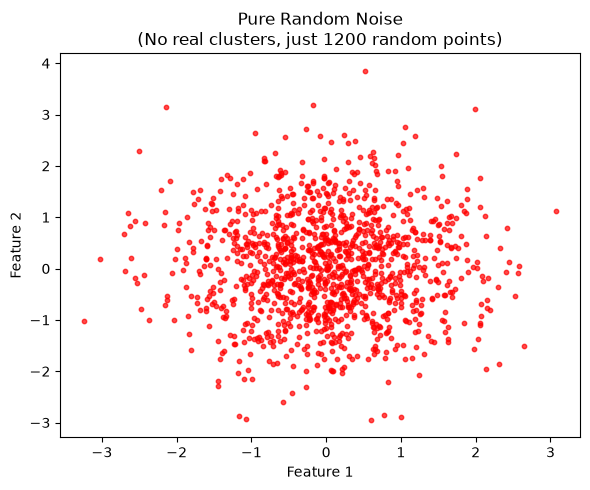

✓ No clusters here — just noise!


In [15]:
# Pure random noise — NO real structure
np.random.seed(SEED)
X_noise = np.random.normal(size=(1200, 2))

print("Pure random noise created (1200 random points)")

# Visualize
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(X_noise[:, 0], X_noise[:, 1], s=10, alpha=0.7, color='red')
ax.set_title('Pure Random Noise\n(No real clusters, just 1200 random points)')
ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')
plt.tight_layout()
plt.show()

print("✓ No clusters here — just noise!")

In [16]:
# K-Means on noise (k=2 to k=10)
k_range = range(2, 11)
silhouettes_noise = []

for k in k_range:
    model = KMeans(n_clusters=k, n_init=10, random_state=SEED)
    labels = model.fit_predict(X_noise)
    sil_score = silhouette_score(X_noise, labels)
    silhouettes_noise.append(sil_score)
    print(f"k = {k}  →  silhouette score = {sil_score:.4f}")

best_k_noise = list(k_range)[np.argmax(silhouettes_noise)]
print(f"\n⚠️  K-Means thinks the best k is: {best_k_noise}")
print(f"Peak silhouette on NOISE: {max(silhouettes_noise):.4f}")

k = 2  →  silhouette score = 0.3159
k = 3  →  silhouette score = 0.3305
k = 4  →  silhouette score = 0.3149
k = 5  →  silhouette score = 0.3122
k = 6  →  silhouette score = 0.3274
k = 7  →  silhouette score = 0.3259
k = 8  →  silhouette score = 0.3165
k = 9  →  silhouette score = 0.3243
k = 10  →  silhouette score = 0.3229

⚠️  K-Means thinks the best k is: 3
Peak silhouette on NOISE: 0.3305


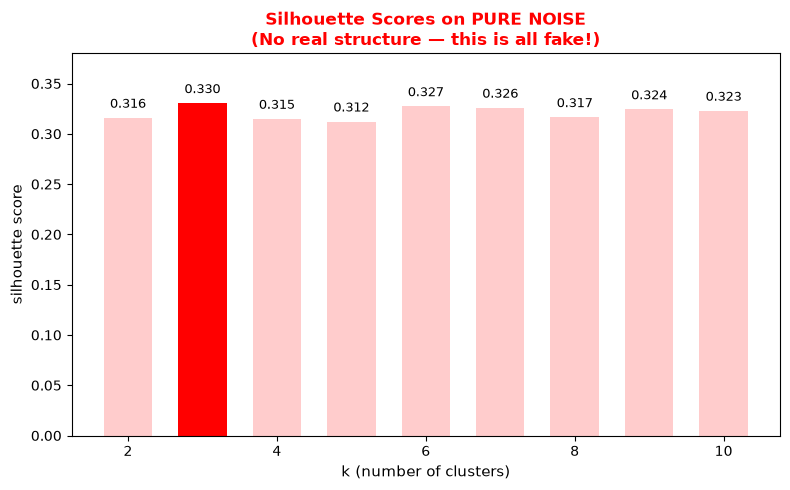

Peak: 0.3305 at k=3


In [17]:
# Plot silhouette scores on noise
best_k_noise = list(k_range)[int(np.argmax(silhouettes_noise))]

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['red' if k == best_k_noise else '#ffcccc' for k in k_range]
bars = ax.bar(list(k_range), silhouettes_noise, color=colors, width=0.65)

# Add values on bars
for k, s in zip(k_range, silhouettes_noise):
    ax.text(k, s + 0.01, f'{s:.3f}', ha='center', fontsize=9)

ax.set_xlabel('k (number of clusters)', fontsize=11)
ax.set_ylabel('silhouette score', fontsize=11)
ax.set_title('Silhouette Scores on PURE NOISE\n(No real structure — this is all fake!)', 
             fontsize=12, fontweight='bold', color='red')
ax.set_ylim(0, max(silhouettes_noise) * 1.15)
plt.tight_layout()
plt.show()

print(f"Peak: {max(silhouettes_noise):.4f} at k={best_k_noise}")

In [18]:
# Compare: Real structure vs Noise
print("="*60)
print("COMPARISON: REAL DATA vs PURE NOISE")
print("="*60)

# Go back to original data (cluster_std=1.15)
X_real, y_real = make_blobs(
    n_samples=1200,
    centers=4,
    n_features=2,
    cluster_std=1.15,
    random_state=SEED,
)

silhouettes_real = []
for k in k_range:
    model = KMeans(n_clusters=k, n_init=10, random_state=SEED)
    labels = model.fit_predict(X_real)
    sil_score = silhouette_score(X_real, labels)
    silhouettes_real.append(sil_score)

print(f"\n📊 REAL DATA (4 clusters, std=1.15):")
print(f"   Peak silhouette: {max(silhouettes_real):.4f}")
print(f"   Peak at k={list(k_range)[np.argmax(silhouettes_real)]}")

print(f"\n⚠️  PURE NOISE (no real structure):")
print(f"   Peak silhouette: {max(silhouettes_noise):.4f}")
print(f"   Peak at k={best_k_noise}")

print(f"\n📈 Difference: {max(silhouettes_real) - max(silhouettes_noise):.4f}")
print(f"\n💡 Question: Where would YOU set the threshold for 'this is probably NOT real'?")

COMPARISON: REAL DATA vs PURE NOISE

📊 REAL DATA (4 clusters, std=1.15):
   Peak silhouette: 0.7625
   Peak at k=4

⚠️  PURE NOISE (no real structure):
   Peak silhouette: 0.3305
   Peak at k=3

📈 Difference: 0.4321

💡 Question: Where would YOU set the threshold for 'this is probably NOT real'?


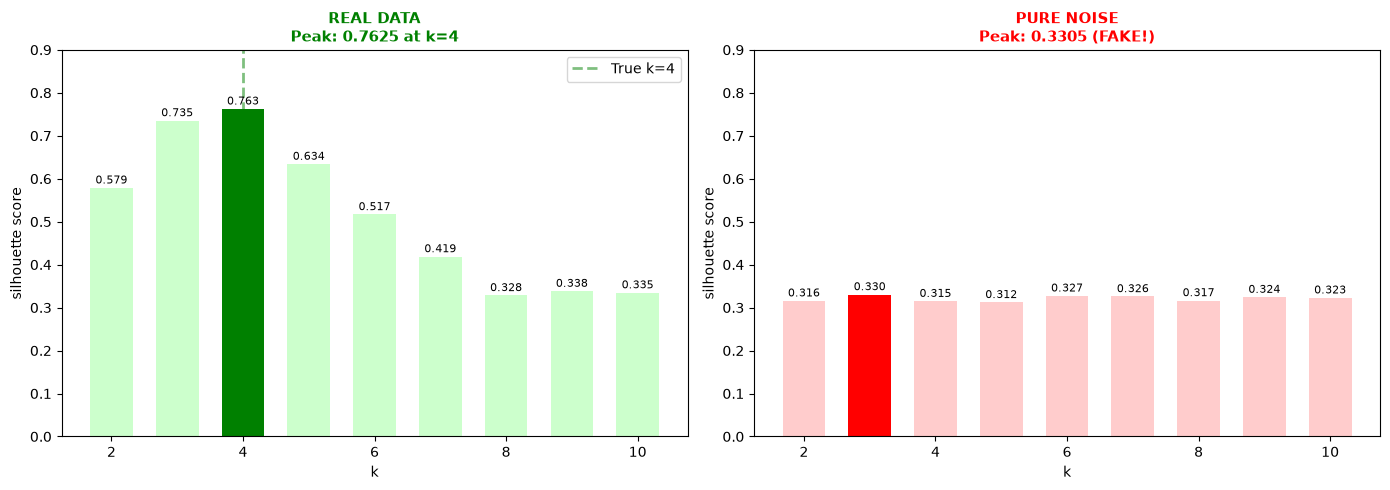

In [19]:
# Side-by-side comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Real data
colors_real = ['green' if k == 4 else '#ccffcc' for k in k_range]
ax1.bar(list(k_range), silhouettes_real, color=colors_real, width=0.65)
ax1.axvline(4, color='green', linestyle='--', linewidth=2, alpha=0.5, label='True k=4')
for k, s in zip(k_range, silhouettes_real):
    ax1.text(k, s + 0.01, f'{s:.3f}', ha='center', fontsize=8)
ax1.set_xlabel('k')
ax1.set_ylabel('silhouette score')
ax1.set_title(f'REAL DATA\nPeak: {max(silhouettes_real):.4f} at k=4', 
              fontsize=11, fontweight='bold', color='green')
ax1.set_ylim(0, 0.9)
ax1.legend()

# Noise
colors_noise = ['red' if k == best_k_noise else '#ffcccc' for k in k_range]
ax2.bar(list(k_range), silhouettes_noise, color=colors_noise, width=0.65)
for k, s in zip(k_range, silhouettes_noise):
    ax2.text(k, s + 0.01, f'{s:.3f}', ha='center', fontsize=8)
ax2.set_xlabel('k')
ax2.set_ylabel('silhouette score')
ax2.set_title(f'PURE NOISE\nPeak: {max(silhouettes_noise):.4f} (FAKE!)', 
              fontsize=11, fontweight='bold', color='red')
ax2.set_ylim(0, 0.9)

plt.tight_layout()
plt.show()

In [20]:
def find_elbow(k_range, inertias):
    """
    Find the elbow point in an inertia curve.
    
    The elbow is the point furthest from the line connecting 
    the first and last points of the curve.
    
    Returns: the k value at the elbow
    """
    # Convert to numpy arrays
    k_values = np.array(list(k_range))
    inertia_values = np.array(inertias)
    
    # Get first and last points
    p1 = np.array([k_values[0], inertia_values[0]])      # First point
    p2 = np.array([k_values[-1], inertia_values[-1]])    # Last point
    
    # Direction vector from p1 to p2
    line_vec = p2 - p1
    line_len = np.linalg.norm(line_vec)
    line_unitvec = line_vec / line_len
    
    # Calculate distance from each point to the line
    distances = []
    for i, k in enumerate(k_values):
        point = np.array([k, inertia_values[i]])
        point_vec = point - p1
        
        # Project point onto line
        proj_length = np.dot(point_vec, line_unitvec)
        proj_point = p1 + proj_length * line_unitvec
        
        # Distance from point to its projection
        distance = np.linalg.norm(point - proj_point)
        distances.append(distance)
    
    # Find the point with maximum distance
    elbow_idx = np.argmax(distances)
    elbow_k = k_values[elbow_idx]
    
    return elbow_k, distances

print("✅ Elbow-finding function created!")

✅ Elbow-finding function created!


In [21]:
# First, recalculate inertias for original data (cluster_std=1.15)
X_original, _ = make_blobs(
    n_samples=1200,
    centers=4,
    n_features=2,
    cluster_std=1.15,  # Original
    random_state=SEED,
)

k_range = range(2, 11)
inertias_original = []

for k in k_range:
    model = KMeans(n_clusters=k, n_init=10, random_state=SEED)
    model.fit(X_original)
    inertias_original.append(model.inertia_)

print("Inertias on ORIGINAL data (cluster_std=1.15):")
for k, inertia in zip(k_range, inertias_original):
    print(f"  k={k}: {inertia:.2f}")

# Find elbow
elbow_k_original, distances_original = find_elbow(k_range, inertias_original)
print(f"\n✅ Elbow found at: k = {elbow_k_original}")

Inertias on ORIGINAL data (cluster_std=1.15):
  k=2: 39144.56
  k=3: 9626.88
  k=4: 3068.64
  k=5: 2776.71
  k=6: 2490.89
  k=7: 2239.72
  k=8: 1978.28
  k=9: 1800.26
  k=10: 1652.76

✅ Elbow found at: k = 4


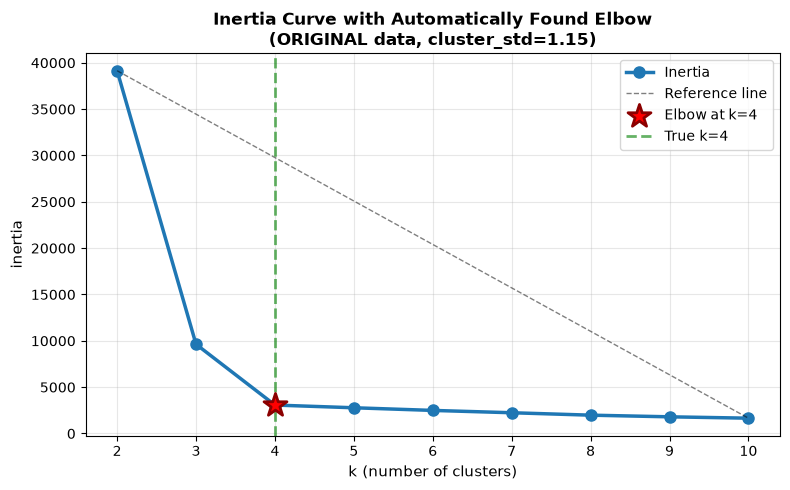

Elbow at k=4
True k=4
Match? True


In [22]:
# Plot inertia with the elbow marked
fig, ax = plt.subplots(figsize=(8, 5))

# Plot inertia curve
ax.plot(list(k_range), inertias_original, 'o-', color=BLUE, linewidth=2.5, markersize=8, label='Inertia')

# Draw the reference line (from first to last point)
k_first, k_last = 2, 10
inertia_first = inertias_original[0]
inertia_last = inertias_original[-1]
ax.plot([k_first, k_last], [inertia_first, inertia_last], 'k--', linewidth=1, alpha=0.5, label='Reference line')

# Mark the elbow
elbow_inertia = inertias_original[elbow_k_original - 2]  # Adjust index
ax.scatter([elbow_k_original], [elbow_inertia], color='red', s=300, marker='*', 
           edgecolors='darkred', linewidths=2, zorder=5, label=f'Elbow at k={elbow_k_original}')

# Mark the TRUE k
ax.axvline(4, color='green', linestyle='--', linewidth=2, alpha=0.6, label='True k=4')

ax.set_xlabel('k (number of clusters)', fontsize=11)
ax.set_ylabel('inertia', fontsize=11)
ax.set_title('Inertia Curve with Automatically Found Elbow\n(ORIGINAL data, cluster_std=1.15)', 
             fontsize=12, fontweight='bold')
ax.legend(frameon=True, fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Elbow at k={elbow_k_original}")
print(f"True k=4")
print(f"Match? {elbow_k_original == 4}")

In [23]:
# Create harder data (overlapping clusters)
X_hard, _ = make_blobs(
    n_samples=1200,
    centers=4,
    n_features=2,
    cluster_std=2.5,  # Harder!
    random_state=SEED,
)

inertias_hard = []

for k in k_range:
    model = KMeans(n_clusters=k, n_init=10, random_state=SEED)
    model.fit(X_hard)
    inertias_hard.append(model.inertia_)

print("Inertias on HARD data (cluster_std=2.5):")
for k, inertia in zip(k_range, inertias_hard):
    print(f"  k={k}: {inertia:.2f}")

# Find elbow
elbow_k_hard, distances_hard = find_elbow(k_range, inertias_hard)
print(f"\n✅ Elbow found at: k = {elbow_k_hard}")

Inertias on HARD data (cluster_std=2.5):
  k=2: 51227.36
  k=3: 20485.73
  k=4: 13335.43
  k=5: 11923.87
  k=6: 10556.91
  k=7: 9253.66
  k=8: 8234.71
  k=9: 7486.81
  k=10: 6747.22

✅ Elbow found at: k = 4


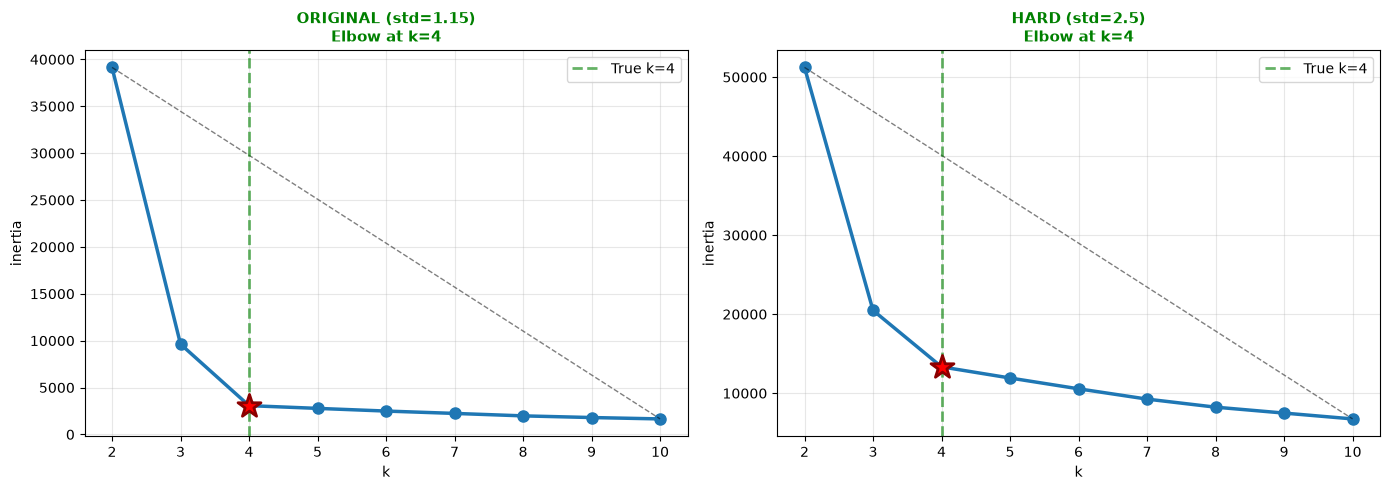


📊 COMPARISON:
  Original (std=1.15): Elbow at k=4 (true k=4) ✅
  Hard (std=2.5):      Elbow at k=4 (true k=4) ✅


In [24]:
# Side-by-side comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# ORIGINAL data
ax1.plot(list(k_range), inertias_original, 'o-', color=BLUE, linewidth=2.5, markersize=8)
ax1.plot([2, 10], [inertias_original[0], inertias_original[-1]], 'k--', linewidth=1, alpha=0.5)
ax1.scatter([elbow_k_original], [inertias_original[elbow_k_original - 2]], 
            color='red', s=300, marker='*', edgecolors='darkred', linewidths=2, zorder=5)
ax1.axvline(4, color='green', linestyle='--', linewidth=2, alpha=0.6, label='True k=4')
ax1.set_xlabel('k')
ax1.set_ylabel('inertia')
ax1.set_title(f'ORIGINAL (std=1.15)\nElbow at k={elbow_k_original}', 
              fontsize=11, fontweight='bold', color='green' if elbow_k_original == 4 else 'red')
ax1.legend()
ax1.grid(True, alpha=0.3)

# HARD data
ax2.plot(list(k_range), inertias_hard, 'o-', color=BLUE, linewidth=2.5, markersize=8)
ax2.plot([2, 10], [inertias_hard[0], inertias_hard[-1]], 'k--', linewidth=1, alpha=0.5)
ax2.scatter([elbow_k_hard], [inertias_hard[elbow_k_hard - 2]], 
            color='red', s=300, marker='*', edgecolors='darkred', linewidths=2, zorder=5)
ax2.axvline(4, color='green', linestyle='--', linewidth=2, alpha=0.6, label='True k=4')
ax2.set_xlabel('k')
ax2.set_ylabel('inertia')
ax2.set_title(f'HARD (std=2.5)\nElbow at k={elbow_k_hard}', 
              fontsize=11, fontweight='bold', color='green' if elbow_k_hard == 4 else 'orange')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n📊 COMPARISON:")
print(f"  Original (std=1.15): Elbow at k={elbow_k_original} (true k=4) ✅" if elbow_k_original == 4 else f"  Original (std=1.15): Elbow at k={elbow_k_original} (true k=4) ❌")
print(f"  Hard (std=2.5):      Elbow at k={elbow_k_hard} (true k=4)" + (" ✅" if elbow_k_hard == 4 else " ⚠️"))

In [25]:
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler

# Load wine dataset
wine = load_wine()
X_wine = wine.data
y_wine_true = wine.target  # Lock this away until the end!

print("Wine Dataset:")
print(f"  Samples: {X_wine.shape[0]}")
print(f"  Features: {X_wine.shape[1]}")
print(f"  True classes: {np.unique(y_wine_true)}")
print(f"  True cluster sizes: {np.bincount(y_wine_true)}")

# Standardize (CRITICAL for clustering!)
scaler = StandardScaler()
X_wine_scaled = scaler.fit_transform(X_wine)

print(f"\n✓ Data standardized")
print(f"  Mean: {X_wine_scaled.mean(axis=0).mean():.6f} (should be ~0)")
print(f"  Std:  {X_wine_scaled.std(axis=0).mean():.6f} (should be ~1)")

Wine Dataset:
  Samples: 178
  Features: 13
  True classes: [0 1 2]
  True cluster sizes: [59 71 48]

✓ Data standardized
  Mean: 0.000000 (should be ~0)
  Std:  1.000000 (should be ~1)


In [26]:
# K-Means for different k values
k_range = range(2, 11)
silhouettes_wine = []
inertias_wine = []

for k in k_range:
    model = KMeans(n_clusters=k, n_init=10, random_state=SEED)
    labels = model.fit_predict(X_wine_scaled)
    
    sil_score = silhouette_score(X_wine_scaled, labels)
    silhouettes_wine.append(sil_score)
    inertias_wine.append(model.inertia_)
    
    print(f"k = {k}  →  silhouette = {sil_score:.4f}  →  inertia = {model.inertia_:.2f}")

# Find metrics
best_k_silhouette = list(k_range)[np.argmax(silhouettes_wine)]
elbow_k_wine, distances_wine = find_elbow(k_range, inertias_wine)

print(f"\n📊 SILHOUETTE says best k = {best_k_silhouette} (score: {max(silhouettes_wine):.4f})")
print(f"📊 ELBOW says best k = {elbow_k_wine}")

k = 2  →  silhouette = 0.2593  →  inertia = 1658.76
k = 3  →  silhouette = 0.2849  →  inertia = 1277.93
k = 4  →  silhouette = 0.2602  →  inertia = 1175.43
k = 5  →  silhouette = 0.2016  →  inertia = 1109.51
k = 6  →  silhouette = 0.2372  →  inertia = 1046.00
k = 7  →  silhouette = 0.2036  →  inertia = 981.60
k = 8  →  silhouette = 0.1570  →  inertia = 935.20
k = 9  →  silhouette = 0.1499  →  inertia = 889.89
k = 10  →  silhouette = 0.1436  →  inertia = 845.90

📊 SILHOUETTE says best k = 3 (score: 0.2849)
📊 ELBOW says best k = 4


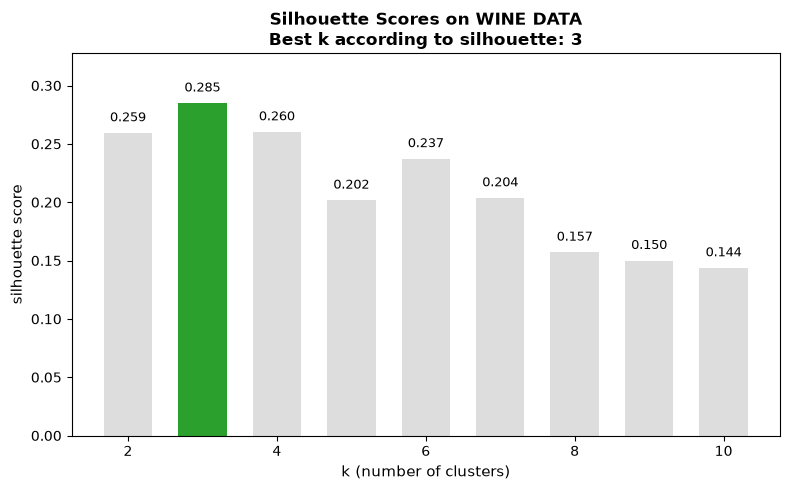

Peak silhouette: 0.2849 at k=3


In [27]:
# Plot silhouette scores
fig, ax = plt.subplots(figsize=(8, 5))
colors = [TEAL if k == best_k_silhouette else PALE for k in k_range]
bars = ax.bar(list(k_range), silhouettes_wine, color=colors, width=0.65)

for k, s in zip(k_range, silhouettes_wine):
    ax.text(k, s + 0.01, f'{s:.3f}', ha='center', fontsize=9)

ax.set_xlabel('k (number of clusters)', fontsize=11)
ax.set_ylabel('silhouette score', fontsize=11)
ax.set_title(f'Silhouette Scores on WINE DATA\nBest k according to silhouette: {best_k_silhouette}', 
             fontsize=12, fontweight='bold')
ax.set_ylim(0, max(silhouettes_wine) * 1.15)
plt.tight_layout()
plt.show()

print(f"Peak silhouette: {max(silhouettes_wine):.4f} at k={best_k_silhouette}")

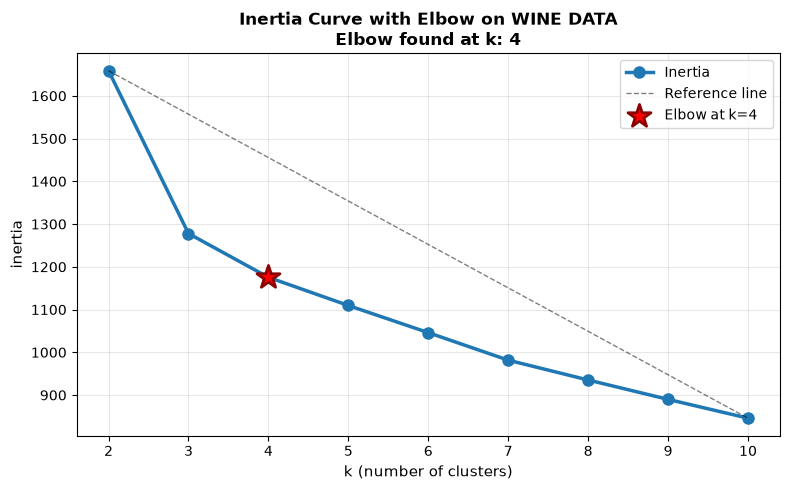

Elbow at k=4


In [28]:
# Plot inertia with elbow
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(list(k_range), inertias_wine, 'o-', color=BLUE, linewidth=2.5, markersize=8, label='Inertia')

# Reference line
k_first, k_last = 2, 10
inertia_first = inertias_wine[0]
inertia_last = inertias_wine[-1]
ax.plot([k_first, k_last], [inertia_first, inertia_last], 'k--', linewidth=1, alpha=0.5, label='Reference line')

# Mark elbow
elbow_inertia = inertias_wine[elbow_k_wine - 2]
ax.scatter([elbow_k_wine], [elbow_inertia], color='red', s=300, marker='*', 
           edgecolors='darkred', linewidths=2, zorder=5, label=f'Elbow at k={elbow_k_wine}')

ax.set_xlabel('k (number of clusters)', fontsize=11)
ax.set_ylabel('inertia', fontsize=11)
ax.set_title(f'Inertia Curve with Elbow on WINE DATA\nElbow found at k: {elbow_k_wine}', 
             fontsize=12, fontweight='bold')
ax.legend(frameon=True, fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Elbow at k={elbow_k_wine}")

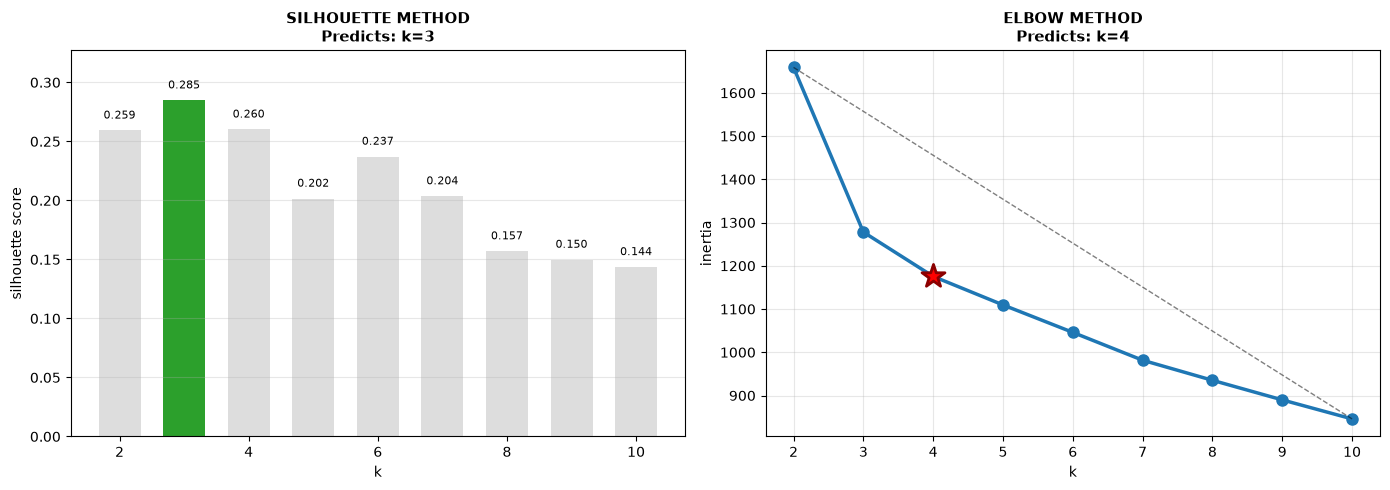


YOUR PREDICTION (before seeing the truth):
Silhouette says: k = 3
Elbow says:      k = 4
⚠️  DISAGREEMENT: Silhouette=3, Elbow=4


In [29]:
# Side-by-side: Silhouette vs Elbow
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Silhouette
colors_sil = [TEAL if k == best_k_silhouette else PALE for k in k_range]
ax1.bar(list(k_range), silhouettes_wine, color=colors_sil, width=0.65)
for k, s in zip(k_range, silhouettes_wine):
    ax1.text(k, s + 0.01, f'{s:.3f}', ha='center', fontsize=8)
ax1.set_xlabel('k')
ax1.set_ylabel('silhouette score')
ax1.set_title(f'SILHOUETTE METHOD\nPredicts: k={best_k_silhouette}', 
              fontsize=11, fontweight='bold')
ax1.set_ylim(0, max(silhouettes_wine) * 1.15)
ax1.grid(True, alpha=0.3, axis='y')

# Elbow
ax2.plot(list(k_range), inertias_wine, 'o-', color=BLUE, linewidth=2.5, markersize=8)
ax2.plot([2, 10], [inertias_wine[0], inertias_wine[-1]], 'k--', linewidth=1, alpha=0.5)
ax2.scatter([elbow_k_wine], [inertias_wine[elbow_k_wine - 2]], 
            color='red', s=300, marker='*', edgecolors='darkred', linewidths=2, zorder=5)
ax2.set_xlabel('k')
ax2.set_ylabel('inertia')
ax2.set_title(f'ELBOW METHOD\nPredicts: k={elbow_k_wine}', 
              fontsize=11, fontweight='bold')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n{'='*60}")
print(f"YOUR PREDICTION (before seeing the truth):")
print(f"{'='*60}")
print(f"Silhouette says: k = {best_k_silhouette}")
print(f"Elbow says:      k = {elbow_k_wine}")
if best_k_silhouette == elbow_k_wine:
    print(f"✅ AGREEMENT: Both predict k = {best_k_silhouette}")
else:
    print(f"⚠️  DISAGREEMENT: Silhouette={best_k_silhouette}, Elbow={elbow_k_wine}")
print(f"{'='*60}")

In [30]:
print(f"\n{'='*60}")
print(f"🔓 REVEALING THE TRUE ANSWER:")
print(f"{'='*60}")

TRUE_K_WINE = len(np.unique(y_wine_true))
print(f"✓ Wine dataset has TRUE {TRUE_K_WINE} classes:")
for i, count in enumerate(np.bincount(y_wine_true)):
    print(f"    Class {i}: {count} samples")

print(f"\n{'='*60}")
print(f"COMPARISON:")
print(f"{'='*60}")
print(f"True answer:     k = {TRUE_K_WINE}")
print(f"Silhouette pred: k = {best_k_silhouette}" + (" ✅" if best_k_silhouette == TRUE_K_WINE else " ❌"))
print(f"Elbow pred:      k = {elbow_k_wine}" + (" ✅" if elbow_k_wine == TRUE_K_WINE else " ❌"))

if best_k_silhouette == TRUE_K_WINE and elbow_k_wine == TRUE_K_WINE:
    print(f"\n🎉 BOTH methods got it right!")
elif best_k_silhouette == TRUE_K_WINE:
    print(f"\n✅ Silhouette was correct, elbow was wrong")
elif elbow_k_wine == TRUE_K_WINE:
    print(f"\n✅ Elbow was correct, silhouette was wrong")
else:
    print(f"\n⚠️  BOTH methods were wrong! (This happens with real data)")
    print(f"   Why? {TRUE_K_WINE} might be an artifact of the labeling,")
    print(f"   not the actual natural clusters in the data.")

print(f"{'='*60}")


🔓 REVEALING THE TRUE ANSWER:
✓ Wine dataset has TRUE 3 classes:
    Class 0: 59 samples
    Class 1: 71 samples
    Class 2: 48 samples

COMPARISON:
True answer:     k = 3
Silhouette pred: k = 3 ✅
Elbow pred:      k = 4 ❌

✅ Silhouette was correct, elbow was wrong


Methods disagreed. Using elbow prediction: k=4


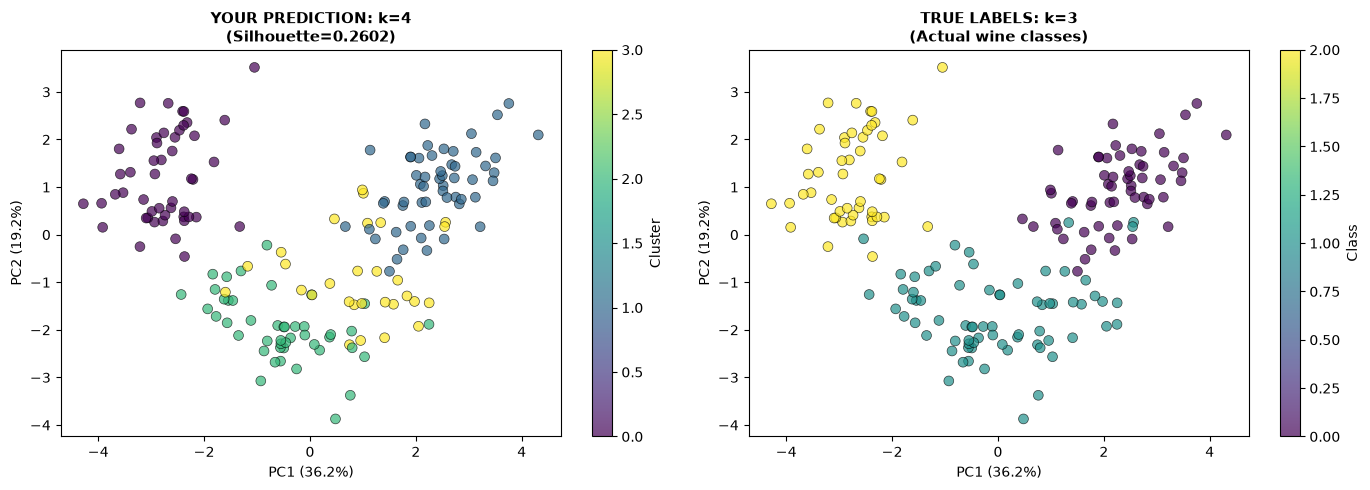


💡 Note: The 2 dimensions shown are PCA projections.
   The clustering is done on all 13 original features.


In [31]:
# Train K-Means with your prediction
if best_k_silhouette == elbow_k_wine:
    YOUR_K = best_k_silhouette
    print(f"Using k={YOUR_K} (both methods agreed)")
else:
    YOUR_K = elbow_k_wine  # Elbow is more reliable
    print(f"Methods disagreed. Using elbow prediction: k={YOUR_K}")

model_wine = KMeans(n_clusters=YOUR_K, n_init=10, random_state=SEED)
your_labels = model_wine.fit_predict(X_wine_scaled)

# Use PCA to visualize (reduce to 2D for plotting)
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_wine_2d = pca.fit_transform(X_wine_scaled)

# Plot your prediction vs true labels
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Your prediction
scatter1 = ax1.scatter(X_wine_2d[:, 0], X_wine_2d[:, 1], c=your_labels, 
                       cmap='viridis', s=50, alpha=0.7, edgecolors='black', linewidth=0.5)
ax1.set_title(f'YOUR PREDICTION: k={YOUR_K}\n(Silhouette={silhouettes_wine[YOUR_K-2]:.4f})', 
              fontsize=11, fontweight='bold')
ax1.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax1.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.colorbar(scatter1, ax=ax1, label='Cluster')

# True labels
scatter2 = ax2.scatter(X_wine_2d[:, 0], X_wine_2d[:, 1], c=y_wine_true, 
                       cmap='viridis', s=50, alpha=0.7, edgecolors='black', linewidth=0.5)
ax2.set_title(f'TRUE LABELS: k={TRUE_K_WINE}\n(Actual wine classes)', 
              fontsize=11, fontweight='bold')
ax2.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax2.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.colorbar(scatter2, ax=ax2, label='Class')

plt.tight_layout()
plt.show()

print(f"\n💡 Note: The 2 dimensions shown are PCA projections.")
print(f"   The clustering is done on all 13 original features.")